In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Python ML environment is ready!")
print("Python packages loaded successfully.")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Python ML environment is ready!
Python packages loaded successfully.
Pandas: 3.0.5
NumPy: 2.5.2
Scikit-learn: 1.9.0


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check the data type
print(df["TotalCharges"].dtype)

float64


In [6]:
# Check missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
# Fill missing TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Check again
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Missing TotalCharges: 0


In [8]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
# Check for duplicate customer IDs
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate customer IDs: 0


In [10]:
# Check the distribution of Churn
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


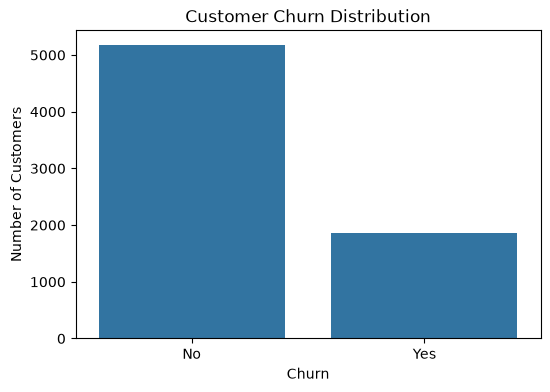

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [12]:
# Contract type vs Churn
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

print(contract_churn)

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


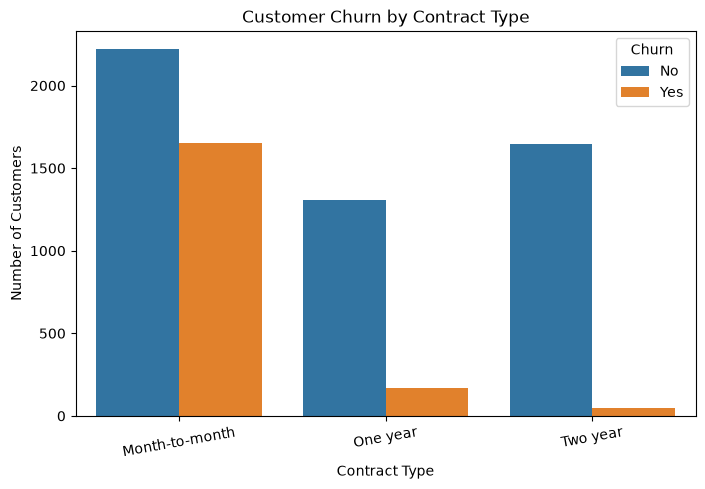

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=10)

plt.show()

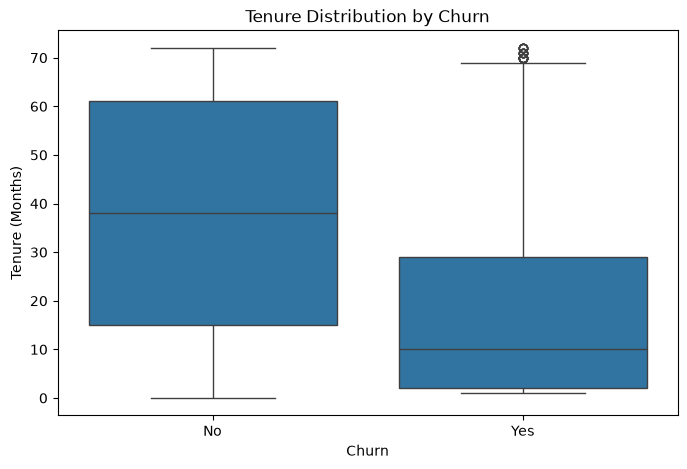

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

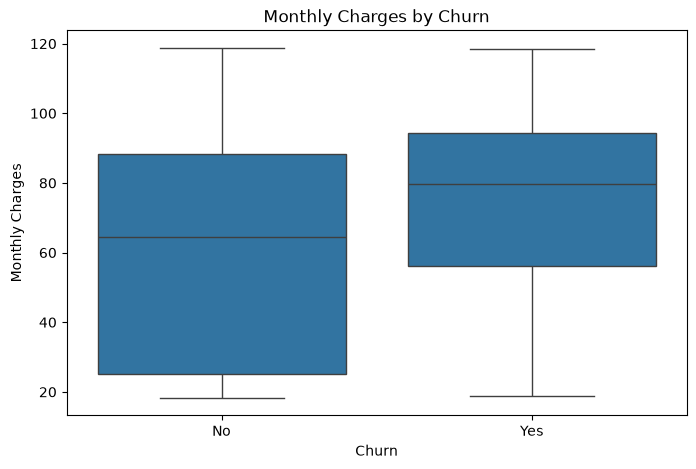

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [16]:
# Internet Service vs Churn

internet_churn = pd.crosstab(df["InternetService"], df["Churn"])

print(internet_churn)

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


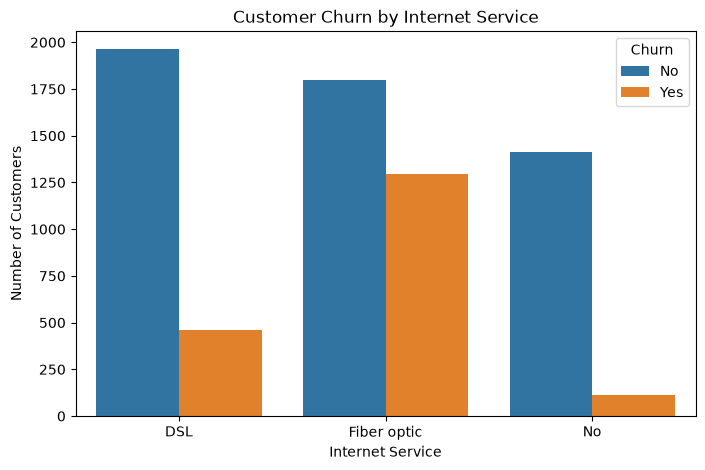

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [18]:
# Payment Method vs Churn

payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"])

print(payment_churn)

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308


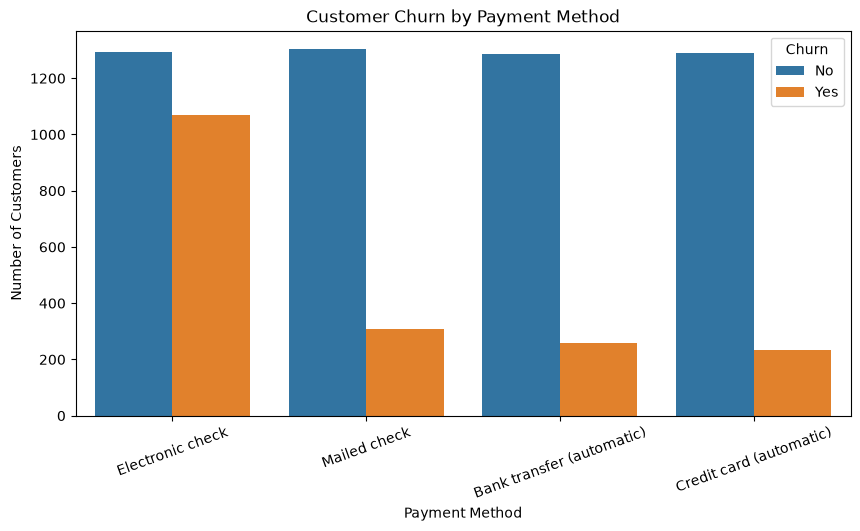

In [19]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

In [20]:
# Senior Citizen vs Churn

senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"])

print(senior_churn)

Churn            No   Yes
SeniorCitizen            
0              4508  1393
1               666   476


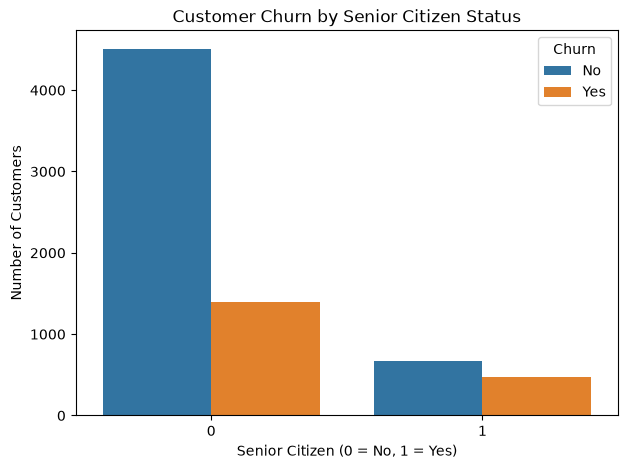

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn")

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [22]:
# Partner vs Churn

partner_churn = pd.crosstab(df["Partner"], df["Churn"])

print(partner_churn)

Churn      No   Yes
Partner            
No       2441  1200
Yes      2733   669


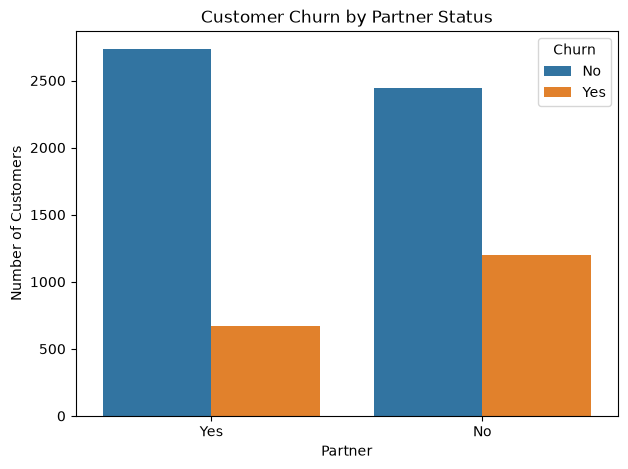

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Partner", hue="Churn")

plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

In [24]:
# Dependents vs Churn

dependents_churn = pd.crosstab(df["Dependents"], df["Churn"])

print(dependents_churn)

Churn         No   Yes
Dependents            
No          3390  1543
Yes         1784   326


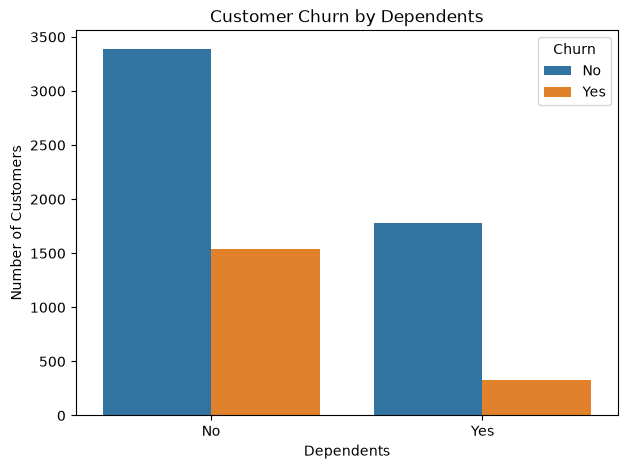

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Dependents", hue="Churn")

plt.title("Customer Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

In [26]:
# Step 17 - Missing Values Check

missing_values = df.isnull().sum()

print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [27]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


In [28]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [29]:
# Step 18 - Duplicate Check

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [30]:
# Step 19 - Remove Customer ID

df_model = df.drop("customerID", axis=1)

print(df_model.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [31]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [32]:
y = y.map({"No": 0, "Yes": 1})

print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [33]:
# Step 20 - One-Hot Encoding

X_encoded = pd.get_dummies(X, drop_first=True)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (7043, 19)
Encoded X shape: (7043, 30)


In [34]:
print(X_encoded.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                            True              False  ...   
1                           False              False  ...   
2                           False              False  ...   
3               

In [35]:
# Step 21 - Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409,)


In [36]:
# Step 22 - Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (5634, 30)
X_test_scaled shape: (1409, 30)


In [37]:
scaler.transform(X_test)

array([[-0.44177295,  1.60848343,  1.62997635, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [ 2.2636062 , -0.9966836 ,  1.16872526, ...,  1.90910518,
        -0.71078107, -0.54384572],
       [-0.44177295,  0.34660565,  0.44532428, ...,  1.90910518,
        -0.71078107, -0.54384572],
       ...,
       [-0.44177295, -1.11880081, -1.46936546, ..., -0.52380561,
        -0.71078107, -0.54384572],
       [-0.44177295,  0.95719167, -1.50088982, ..., -0.52380561,
        -0.71078107, -0.54384572],
       [-0.44177295,  1.60848343,  0.18317439, ..., -0.52380561,
        -0.71078107, -0.54384572]], shape=(1409, 30))

In [38]:
# Step 23 - Logistic Regression

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [39]:
# Step 24 - Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Predictions
y_pred = log_model.predict(X_test_scaled)

# Probability predictions
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.807
Precision: 0.6584
Recall   : 0.5668
F1-Score : 0.6092
ROC-AUC  : 0.8418


In [40]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[925 110]
 [162 212]]


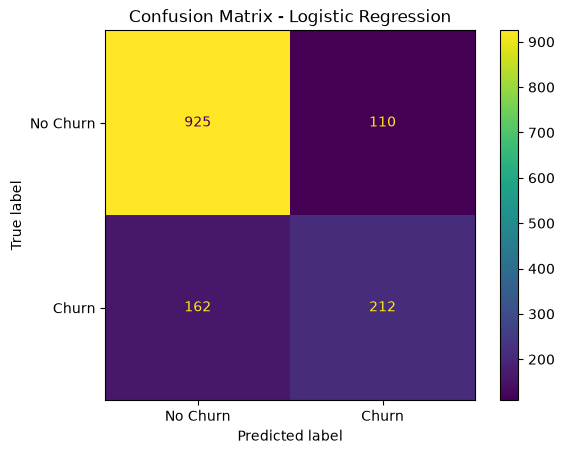

In [42]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [43]:
# Step 26 - Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [44]:
# Random Forest Predictions

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Predictions completed!")

Predictions completed!


In [45]:
# Step 27 - Random Forest Evaluation

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.7743
Precision: 0.566
Recall   : 0.6417
F1-Score : 0.6015
ROC-AUC  : 0.8275


In [46]:
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.57      0.64      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409



In [47]:
# Step 28 - Model Comparison

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred), rf_accuracy],
    "Precision": [precision_score(y_test, y_pred), rf_precision],
    "Recall": [recall_score(y_test, y_pred), rf_recall],
    "F1-Score": [f1_score(y_test, y_pred), rf_f1],
    "ROC-AUC": [roc_auc_score(y_test, y_prob), rf_roc_auc]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.806955,0.658385,0.566845,0.609195,0.841778
1,Random Forest,0.774308,0.566038,0.641711,0.601504,0.827501


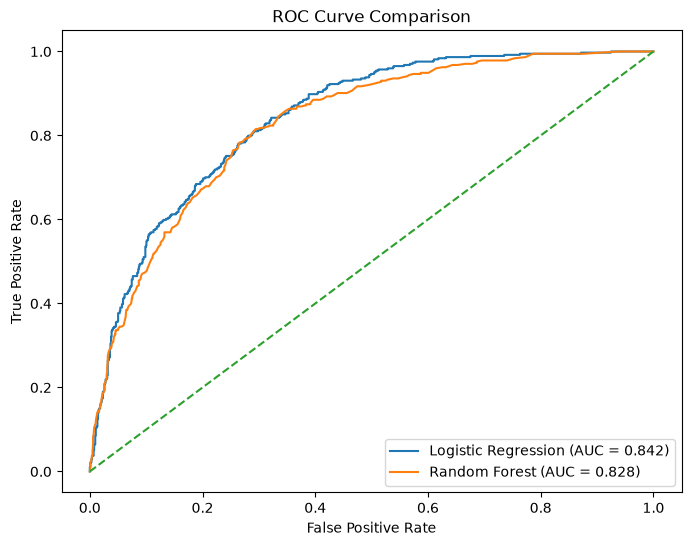

In [48]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ROC Curve - Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)

# ROC Curve - Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [49]:
# Step 30 - Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                                  Feature  Importance
3                            TotalCharges    0.176915
1                                  tenure    0.165664
2                          MonthlyCharges    0.151647
25                      Contract_Two year    0.058577
10            InternetService_Fiber optic    0.043664
28         PaymentMethod_Electronic check    0.037028
24                      Contract_One year    0.029995
13                     OnlineSecurity_Yes    0.028289
4                             gender_Male    0.025872
26                   PaperlessBilling_Yes    0.023761
19                        TechSupport_Yes    0.022197
5                             Partner_Yes    0.020944
15                       OnlineBackup_Yes    0.020302
6                          Dependents_Yes    0.019179
17                   DeviceProtection_Yes    0.017923
9                       MultipleLines_Yes    0.017500
0                           SeniorCitizen    0.017431
23                    Stream

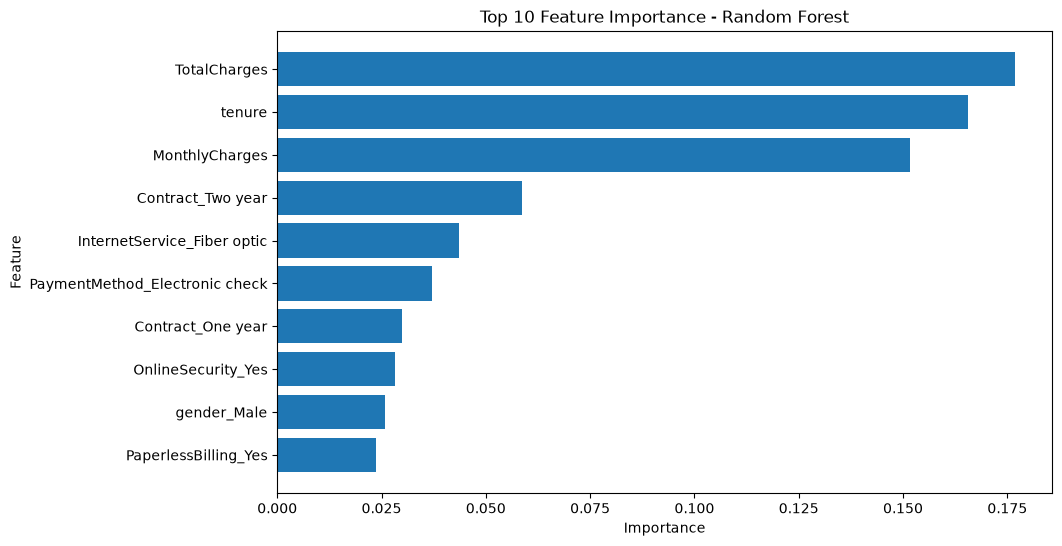

In [50]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(10)[::-1],
    feature_importance["Importance"].head(10)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")

plt.show()